# GeBIZ Tender Dataset - Business Intelligence & Visualization

## Purpose
This notebook explores classified government procurement (GeBIZ) tender award data to help you understand:
- **Spending patterns**: Where is the money going?
- **Business categories**: What types of services/products are being procured?
- **Key players**: Which agencies spend the most? Which suppliers win the most contracts?
- **Service types**: Which categories have recurring services? Which are manpower-heavy?
- **Future opportunities**: Where can forecasting and planning focus?

## Data Source
- **Input**: `Dataset/Final/GPGB_enriched_final.csv`
- **Contains**: 12,572 tender records with procurement type, business category, and service flags
- **Important**: Original CSV is read-only. All analysis happens in this notebook.

## Setup & Configuration

In [1]:
# Import libraries
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configure visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

# Create output directory
output_dir = Path("Dataset") / "Visualisation"
output_dir.mkdir(exist_ok=True)

print(f"✓ Output directory created: {output_dir}")

✓ Output directory created: Dataset\Visualisation


## 1. Load and Validate Data

In [2]:
# Load data
data_path = Path("Dataset") / "Final" / "GPGB_enriched_final.csv"
df_raw = pd.read_csv(data_path)

print(f"\n{'='*80}")
print("DATA LOAD SUMMARY")
print(f"{'='*80}\n")

print(f"Total rows loaded: {len(df_raw):,}")
print(f"Total columns: {len(df_raw.columns)}")

# Key validations
print(f"\nKEY METRICS:")
print(f"  Unique tender numbers: {df_raw['tender_no'].nunique():,}")
print(f"  Unique agencies: {df_raw['agency'].nunique():,}")
print(f"  Unique suppliers: {df_raw['supplier_name'].nunique():,}")
print(f"  Date range: {df_raw['award_date'].min()} to {df_raw['award_date'].max()}")
print(f"  Total awarded amount: ${df_raw['awarded_amt'].sum():,.2f}")

# Missing values
print(f"\nMISSING VALUES:")
missing = df_raw.isnull().sum()
for col in missing[missing > 0].index:
    pct = missing[col] / len(df_raw) * 100
    print(f"  {col}: {missing[col]:,} ({pct:.1f}%)")

# Data types
print(f"\nCOLUMN DATA TYPES:")
for col in df_raw.columns:
    print(f"  {col}: {df_raw[col].dtype}")


DATA LOAD SUMMARY

Total rows loaded: 12,572
Total columns: 11

KEY METRICS:
  Unique tender numbers: 7,921
  Unique agencies: 111
  Unique suppliers: 4,726
  Date range: 1/1/2023 to 9/9/2024
  Total awarded amount: $56,449,935,834.91

MISSING VALUES:

COLUMN DATA TYPES:
  tender_no: str
  tender_description: str
  agency: str
  award_date: str
  tender_detail_status: str
  supplier_name: str
  awarded_amt: float64
  procurement_type: str
  business_category: str
  recurring_service: bool
  manpower_heavy: bool


## 2. Data Preparation

Create analysis-ready columns for deeper insights. This includes:
- Converting awarded_amt to numeric
- Converting award_date to datetime
- Creating time-based columns (year, month, quarter)
- Creating budget buckets for value segmentation
- Creating readable labels

In [3]:
# Create working copy
df = df_raw.copy()

print(f"\n{'='*80}")
print("DATA PREPARATION")
print(f"{'='*80}\n")

# 1. Clean awarded_amt (convert to numeric)
print("Step 1: Cleaning awarded_amt...")
df['awarded_amt'] = pd.to_numeric(df['awarded_amt'], errors='coerce')
print(f"  ✓ Converted to numeric")
print(f"  ✓ Null values: {df['awarded_amt'].isnull().sum():,}")

# 2. Convert award_date to datetime
print(f"\nStep 2: Converting award_date to datetime...")
df['award_date'] = pd.to_datetime(df['award_date'], errors='coerce')
print(f"  ✓ Converted to datetime")
print(f"  ✓ Date range: {df['award_date'].min()} to {df['award_date'].max()}")

# 3. Create time-based columns
print(f"\nStep 3: Creating time-based columns...")
df['award_year'] = df['award_date'].dt.year
df['award_month'] = df['award_date'].dt.month
df['award_quarter'] = df['award_date'].dt.quarter
df['year_month'] = df['award_date'].dt.strftime('%Y-%m')
print(f"  ✓ Created: award_year, award_month, award_quarter, year_month")

# 4. Create budget buckets
print(f"\nStep 4: Creating budget_bucket categorization...")
def assign_budget_bucket(amount):
    if pd.isna(amount) or amount == 0:
        return 'Unknown / $0'
    elif amount < 100000:
        return 'Small (<$100k)'
    elif amount < 1000000:
        return 'Medium ($100k-$1M)'
    elif amount < 10000000:
        return 'Large ($1M-$10M)'
    else:
        return 'Mega (>$10M)'

df['budget_bucket'] = df['awarded_amt'].apply(assign_budget_bucket)
print(f"  ✓ Created: budget_bucket with 5 categories")

# 5. Create readable labels
print(f"\nStep 5: Creating readable labels...")
df['recurring_service_label'] = df['recurring_service'].apply(
    lambda x: 'Recurring' if x == True else ('Non-recurring' if x == False else 'Unknown')
)
df['manpower_heavy_label'] = df['manpower_heavy'].apply(
    lambda x: 'Manpower-heavy' if x == True else ('Not manpower-heavy' if x == False else 'Unknown')
)
print(f"  ✓ Created: recurring_service_label, manpower_heavy_label")

# 6. Create analysis layers
print(f"\nStep 6: Creating analysis layers...")
df_tender_level = df.groupby('tender_no').agg({
    'tender_description': 'first',
    'agency': 'first',
    'award_date': 'first',
    'award_year': 'first',
    'award_month': 'first',
    'award_quarter': 'first',
    'year_month': 'first',
    'tender_detail_status': 'first',
    'awarded_amt': 'sum',
    'procurement_type': 'first',
    'business_category': 'first',
    'recurring_service': 'first',
    'manpower_heavy': 'first',
    'budget_bucket': 'first',
    'recurring_service_label': 'first',
    'manpower_heavy_label': 'first',
    'supplier_name': 'count'  # Count suppliers per tender
}).reset_index()

df_tender_level.rename(columns={'supplier_name': 'num_suppliers'}, inplace=True)
print(f"  ✓ Row-level data: {len(df):,} rows")
print(f"  ✓ Tender-level data: {len(df_tender_level):,} unique tenders")

print(f"\n{'='*80}")
print("PREVIEW OF PREPARED DATA")
print(f"{'='*80}\n")

from IPython.display import display
display(df[[
    'tender_no', 'tender_description', 'agency', 'award_date', 'awarded_amt',
    'procurement_type', 'business_category', 'recurring_service_label',
    'manpower_heavy_label', 'budget_bucket'
]].head(10))


DATA PREPARATION

Step 1: Cleaning awarded_amt...
  ✓ Converted to numeric
  ✓ Null values: 0

Step 2: Converting award_date to datetime...
  ✓ Converted to datetime
  ✓ Date range: 2020-01-04 00:00:00 to 2025-12-03 00:00:00

Step 3: Creating time-based columns...
  ✓ Created: award_year, award_month, award_quarter, year_month

Step 4: Creating budget_bucket categorization...
  ✓ Created: budget_bucket with 5 categories

Step 5: Creating readable labels...
  ✓ Created: recurring_service_label, manpower_heavy_label

Step 6: Creating analysis layers...
  ✓ Row-level data: 12,572 rows
  ✓ Tender-level data: 7,921 unique tenders

PREVIEW OF PREPARED DATA



,tender_no,tender_description,agency,award_date,awarded_amt,procurement_type,business_category,recurring_service_label,manpower_heavy_label,budget_bucket
0,ACR000ETT20300002,INVITATION TO TENDER FOR THE PROVISION OF SERV...,Accounting And Corporate Regulatory Authority,2020-10-11,285000.0,Provision,Training & Development,Recurring,Not manpower-heavy,Medium ($100k-$1M)
1,ACR000ETT20300002,INVITATION TO TENDER FOR THE PROVISION OF SERV...,Accounting And Corporate Regulatory Authority,2020-10-11,90000.0,Provision,Training & Development,Recurring,Not manpower-heavy,Small (<$100k)
2,ACR000ETT20300003,PROVISION OF AN IT SECURITY CONTROLS AND OPERA...,Accounting And Corporate Regulatory Authority,2020-09-12,182400.0,Provision,IT & Systems,Recurring,Not manpower-heavy,Medium ($100k-$1M)
3,ACR000ETT21000001,"DESIGN, DEVELOPMENT, CUSTOMIZATION, DELIVERY, ...",Accounting And Corporate Regulatory Authority,2021-06-09,2321600.0,Maintenance,Transport & Logistics,Recurring,Not manpower-heavy,Large ($1M-$10M)
4,ACR000ETT21000003,"SUPPLY, DELIVERY, INSTALLATION, TESTING, COMMI...",Accounting And Corporate Regulatory Authority,NaT,108555723.0,Provision,Transport & Logistics,Recurring,Not manpower-heavy,Mega (>$10M)
5,ACR000ETT21000004,INVITATION TO TENDER FOR THE APPLICATION SOFTW...,Accounting And Corporate Regulatory Authority,NaT,4503450.0,Maintenance,IT & Systems,Recurring,Not manpower-heavy,Large ($1M-$10M)
6,ACR000ETT22000001,FOR PROVISION OF THE APPLICATION SOFTWARE MAIN...,Accounting And Corporate Regulatory Authority,NaT,539600.0,Provision,IT & Systems,Recurring,Not manpower-heavy,Medium ($100k-$1M)
7,ACR000ETT22000003,INVITATION TO TENDER FOR THE PROVISION OF THE ...,Accounting And Corporate Regulatory Authority,NaT,987850.0,Provision,IT & Systems,Recurring,Not manpower-heavy,Medium ($100k-$1M)
8,ACR000ETT23000001,INVITATION TO TENDER FOR THE PROVISION OF SERV...,Accounting And Corporate Regulatory Authority,NaT,850000.0,Provision,Training & Development,Recurring,Not manpower-heavy,Medium ($100k-$1M)
9,ACR000ETT23000001,INVITATION TO TENDER FOR THE PROVISION OF SERV...,Accounting And Corporate Regulatory Authority,NaT,562500.0,Provision,Training & Development,Recurring,Not manpower-heavy,Medium ($100k-$1M)


## 3. Data Quality Overview

Understand the distribution of classifications and identify any data quality issues.


DATA QUALITY OVERVIEW

CLASSIFICATION STATUS (rows):
  Classified: 9,554 (76.0%)
  Unclassified: 3,018 (24.0%)

CLASSIFICATION STATUS (tender level):
  Classified tenders: 6,145 (77.6%)
  Unclassified tenders: 1,776 (22.4%)

BUSINESS CATEGORY BREAKDOWN (row-level):
  Unclassified: 3,018 (24.0%)
  IT & Systems: 1,795 (14.3%)
  Transport & Logistics: 1,390 (11.1%)
  Professional Services: 1,317 (10.5%)
  Events, Media & Marketing: 963 (7.7%)
  Construction & Engineering: 904 (7.2%)
  Training & Development: 748 (5.9%)
  Facilities & Maintenance: 668 (5.3%)
  Operations & Logistics: 516 (4.1%)
  Healthcare & Social Care: 383 (3.0%)
  Manpower & HR: 364 (2.9%)
  Catering & Food Services: 325 (2.6%)
  Security: 181 (1.4%)

AWARDED AMOUNT QUALITY:
  Null or zero values: 441 (3.5%)
  Valid amounts: 12,131
  Total value: $56,449,935,834.91
  Median value: $160,191.00

PROCUREMENT TYPE BREAKDOWN:
  Provision: 8,422 (67.0%)
  Other: 1,192 (9.5%)
  Contract: 1,137 (9.0%)
  Maintenance: 846 (6.7%

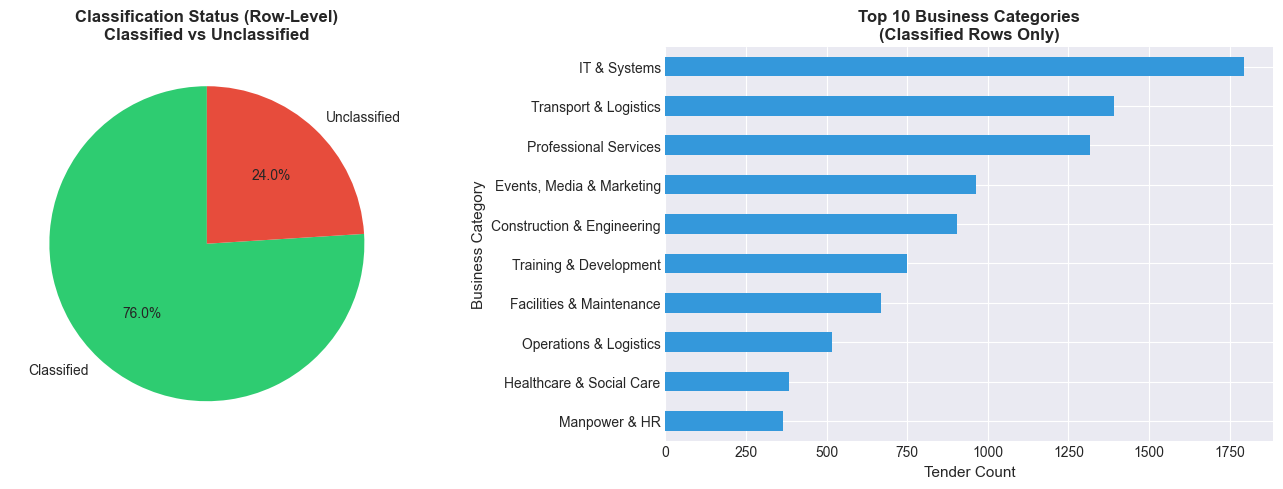


✓ Chart saved: data_quality_overview.png


In [4]:
print(f"\n{'='*80}")
print("DATA QUALITY OVERVIEW")
print(f"{'='*80}\n")

# Classification status
classified = (df['business_category'] != 'Unclassified').sum()
unclassified = (df['business_category'] == 'Unclassified').sum()

print(f"CLASSIFICATION STATUS (rows):")
print(f"  Classified: {classified:,} ({classified/len(df)*100:.1f}%)")
print(f"  Unclassified: {unclassified:,} ({unclassified/len(df)*100:.1f}%)")

# Tender-level classification
classified_tenders = (df_tender_level['business_category'] != 'Unclassified').sum()
unclassified_tenders = (df_tender_level['business_category'] == 'Unclassified').sum()

print(f"\nCLASSIFICATION STATUS (tender level):")
print(f"  Classified tenders: {classified_tenders:,} ({classified_tenders/len(df_tender_level)*100:.1f}%)")
print(f"  Unclassified tenders: {unclassified_tenders:,} ({unclassified_tenders/len(df_tender_level)*100:.1f}%)")

# Business category breakdown (including Unclassified)
print(f"\nBUSINESS CATEGORY BREAKDOWN (row-level):")
cat_breakdown = df['business_category'].value_counts().sort_values(ascending=False)
for cat, count in cat_breakdown.items():
    pct = count / len(df) * 100
    print(f"  {cat}: {count:,} ({pct:.1f}%)")

# Award amount quality
print(f"\nAWARDED AMOUNT QUALITY:")
zero_or_null = df['awarded_amt'].isnull().sum() + (df['awarded_amt'] == 0).sum()
print(f"  Null or zero values: {zero_or_null:,} ({zero_or_null/len(df)*100:.1f}%)")
print(f"  Valid amounts: {len(df) - zero_or_null:,}")
print(f"  Total value: ${df['awarded_amt'].sum():,.2f}")
print(f"  Median value: ${df['awarded_amt'].median():,.2f}")

# Procurement type breakdown
print(f"\nPROCUREMENT TYPE BREAKDOWN:")
ptype_breakdown = df['procurement_type'].value_counts().sort_values(ascending=False)
for ptype, count in ptype_breakdown.items():
    pct = count / len(df) * 100
    print(f"  {ptype}: {count:,} ({pct:.1f}%)")

# Visualization: Classification pie chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Classification pie
class_data = df['business_category'].apply(lambda x: 'Classified' if x != 'Unclassified' else 'Unclassified').value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(class_data.values, labels=class_data.index, autopct='%1.1f%%', colors=colors, startangle=90)
axes[0].set_title('Classification Status (Row-Level)\nClassified vs Unclassified', fontsize=12, fontweight='bold')

# Business category bar chart (top 10, excluding Unclassified)
cat_data = df[df['business_category'] != 'Unclassified']['business_category'].value_counts().head(10)
cat_data.plot(kind='barh', ax=axes[1], color='#3498db')
axes[1].set_xlabel('Tender Count', fontsize=11)
axes[1].set_ylabel('Business Category', fontsize=11)
axes[1].set_title('Top 10 Business Categories\n(Classified Rows Only)', fontsize=12, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(output_dir / 'data_quality_overview.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Chart saved: data_quality_overview.png")

## 4. Business Category Analysis

Deep dive into which business categories are procured most and where spending is concentrated.
**Note**: Unclassified rows excluded from category analysis.


BUSINESS CATEGORY ANALYSIS

Note: Using 6,145 classified tenders

CATEGORY SUMMARY (TENDER-LEVEL):
                            Tender Count  Total Value ($)  Median Value ($)  Average Value ($)
business_category                                                                             
Facilities & Maintenance             543     2.689396e+10        1970938.46        49528465.28
Construction & Engineering           771     6.928727e+09         468870.05         8986676.20
IT & Systems                        1469     5.903543e+09         537600.00         4018749.51
Operations & Logistics               420     3.343412e+09         452994.00         7960505.20
Transport & Logistics                777     2.764169e+09         344000.00         3557489.41
Training & Development               470     9.430305e+08         304400.00         2006447.86
Security                             168     7.132950e+08         666610.84         4245803.35
Professional Services                689     

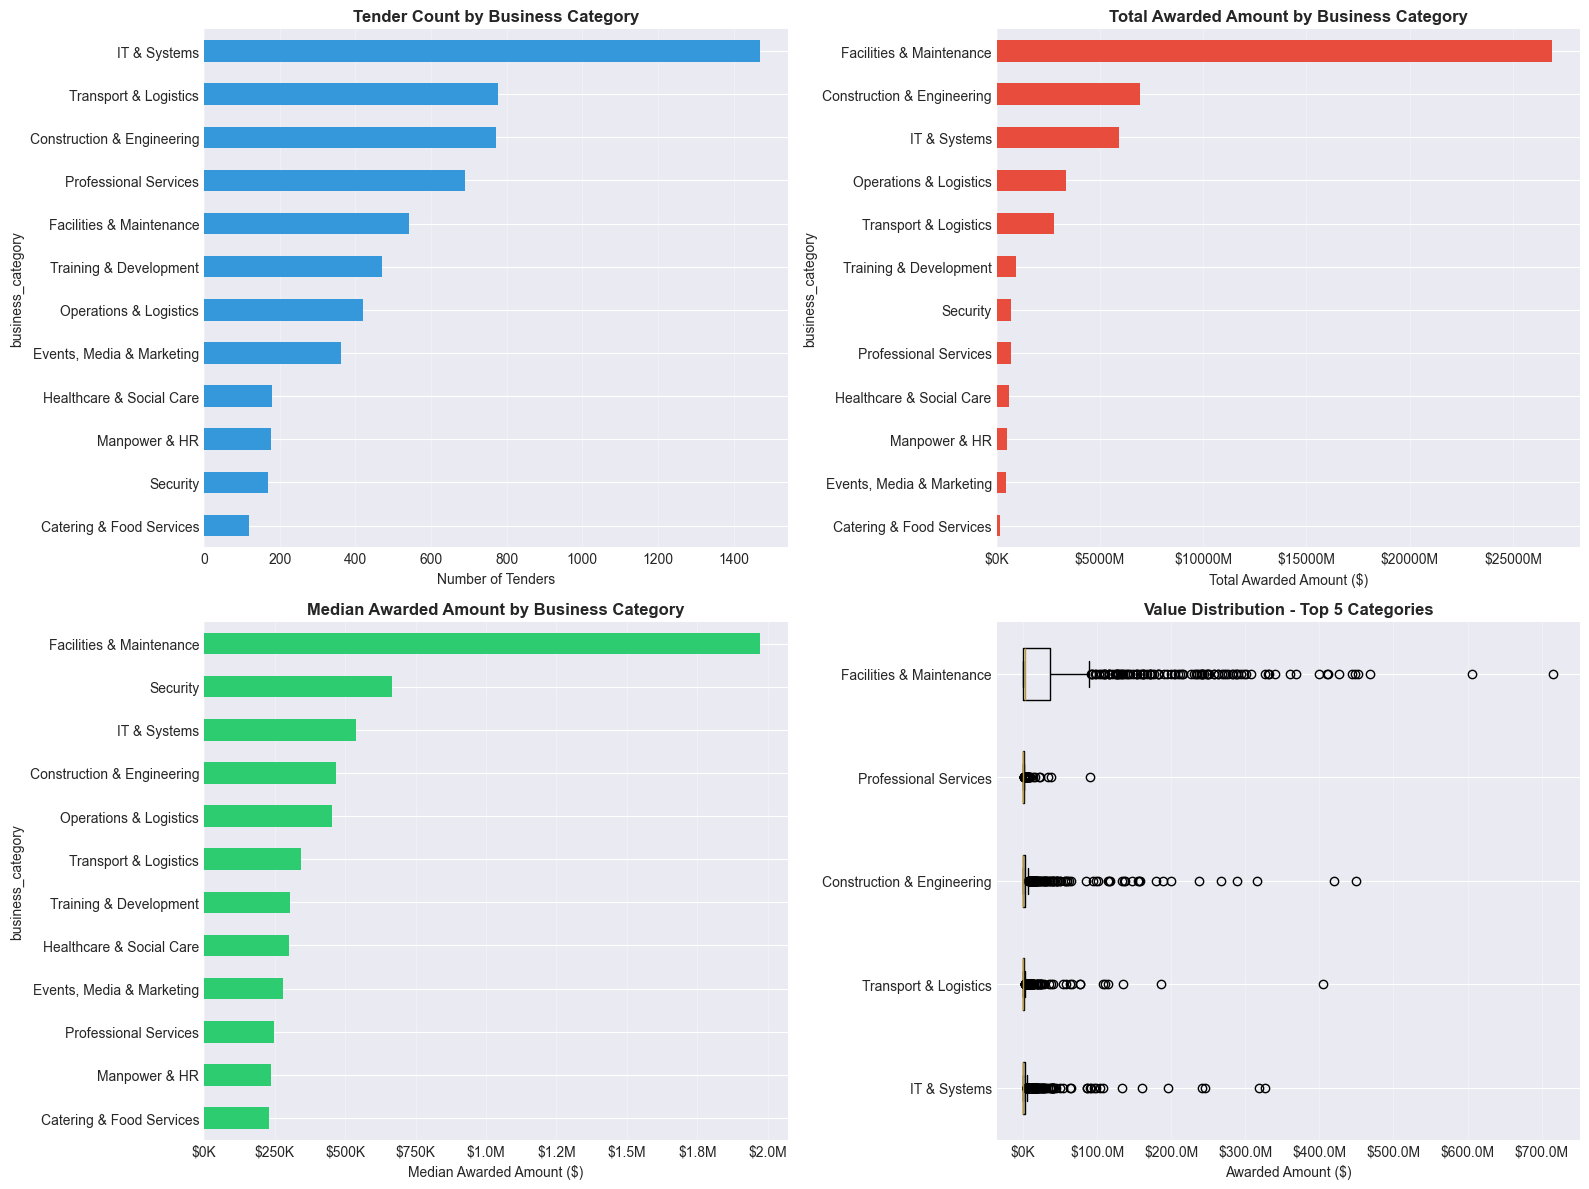


✓ Chart saved: business_category_analysis.png


In [5]:
# Use classified tenders only
df_classified = df[df['business_category'] != 'Unclassified'].copy()
df_classified_tenders = df_tender_level[df_tender_level['business_category'] != 'Unclassified'].copy()

print(f"\n{'='*80}")
print("BUSINESS CATEGORY ANALYSIS")
print(f"{'='*80}\n")
print(f"Note: Using {len(df_classified_tenders):,} classified tenders\n")

# Category summary statistics (use tender-level to avoid double-counting)
category_summary = df_classified_tenders.groupby('business_category').agg({
    'tender_no': 'count',
    'awarded_amt': ['sum', 'median', 'mean']
}).round(2)

category_summary.columns = ['Tender Count', 'Total Value ($)', 'Median Value ($)', 'Average Value ($)']
category_summary = category_summary.sort_values('Total Value ($)', ascending=False)

print("CATEGORY SUMMARY (TENDER-LEVEL):")
print(category_summary.to_string())

# Save category summary
category_summary.to_csv(output_dir / 'category_summary.csv')
print(f"\n✓ Saved: category_summary.csv")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Tender count by category (sorted)
tender_counts = df_classified_tenders['business_category'].value_counts().sort_values()
tender_counts.plot(kind='barh', ax=axes[0, 0], color='#3498db')
axes[0, 0].set_xlabel('Number of Tenders', fontsize=10)
axes[0, 0].set_title('Tender Count by Business Category', fontsize=12, fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3)

# 2. Total awarded amount by category (sorted)
total_value = df_classified_tenders.groupby('business_category')['awarded_amt'].sum().sort_values()
total_value.plot(kind='barh', ax=axes[0, 1], color='#e74c3c')
axes[0, 1].set_xlabel('Total Awarded Amount ($)', fontsize=10)
axes[0, 1].set_title('Total Awarded Amount by Business Category', fontsize=12, fontweight='bold')
axes[0, 1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.0f}M' if x >= 1e6 else f'${x/1e3:.0f}K'))
axes[0, 1].grid(axis='x', alpha=0.3)

# 3. Median awarded amount by category (sorted)
median_value = df_classified_tenders.groupby('business_category')['awarded_amt'].median().sort_values()
median_value.plot(kind='barh', ax=axes[1, 0], color='#2ecc71')
axes[1, 0].set_xlabel('Median Awarded Amount ($)', fontsize=10)
axes[1, 0].set_title('Median Awarded Amount by Business Category', fontsize=12, fontweight='bold')
axes[1, 0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K'))
axes[1, 0].grid(axis='x', alpha=0.3)

# 4. Distribution of tender values by top 5 categories
top5_cats = df_classified_tenders['business_category'].value_counts().head(5).index
data_for_box = [df_classified_tenders[df_classified_tenders['business_category'] == cat]['awarded_amt'].dropna() 
                 for cat in top5_cats]
axes[1, 1].boxplot(data_for_box, labels=top5_cats, vert=False)
axes[1, 1].set_xlabel('Awarded Amount ($)', fontsize=10)
axes[1, 1].set_title('Value Distribution - Top 5 Categories', fontsize=12, fontweight='bold')
axes[1, 1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K'))
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / 'business_category_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Chart saved: business_category_analysis.png")

## 5. Time Trend Analysis

Track how tender volumes and spending have evolved over time.


TIME TREND ANALYSIS

YEARLY TRENDS:
            Tender Count  Total Value ($)  Average Value ($)
award_year                                                  
2020.0               324     1.052718e+09         3249131.02
2021.0               465     2.064597e+09         4439992.64
2022.0               410     2.203834e+09         5375205.78
2023.0               449     2.723624e+09         6065977.33
2024.0               459     2.290862e+09         4990984.39
2025.0               117     8.939205e+08         7640346.18


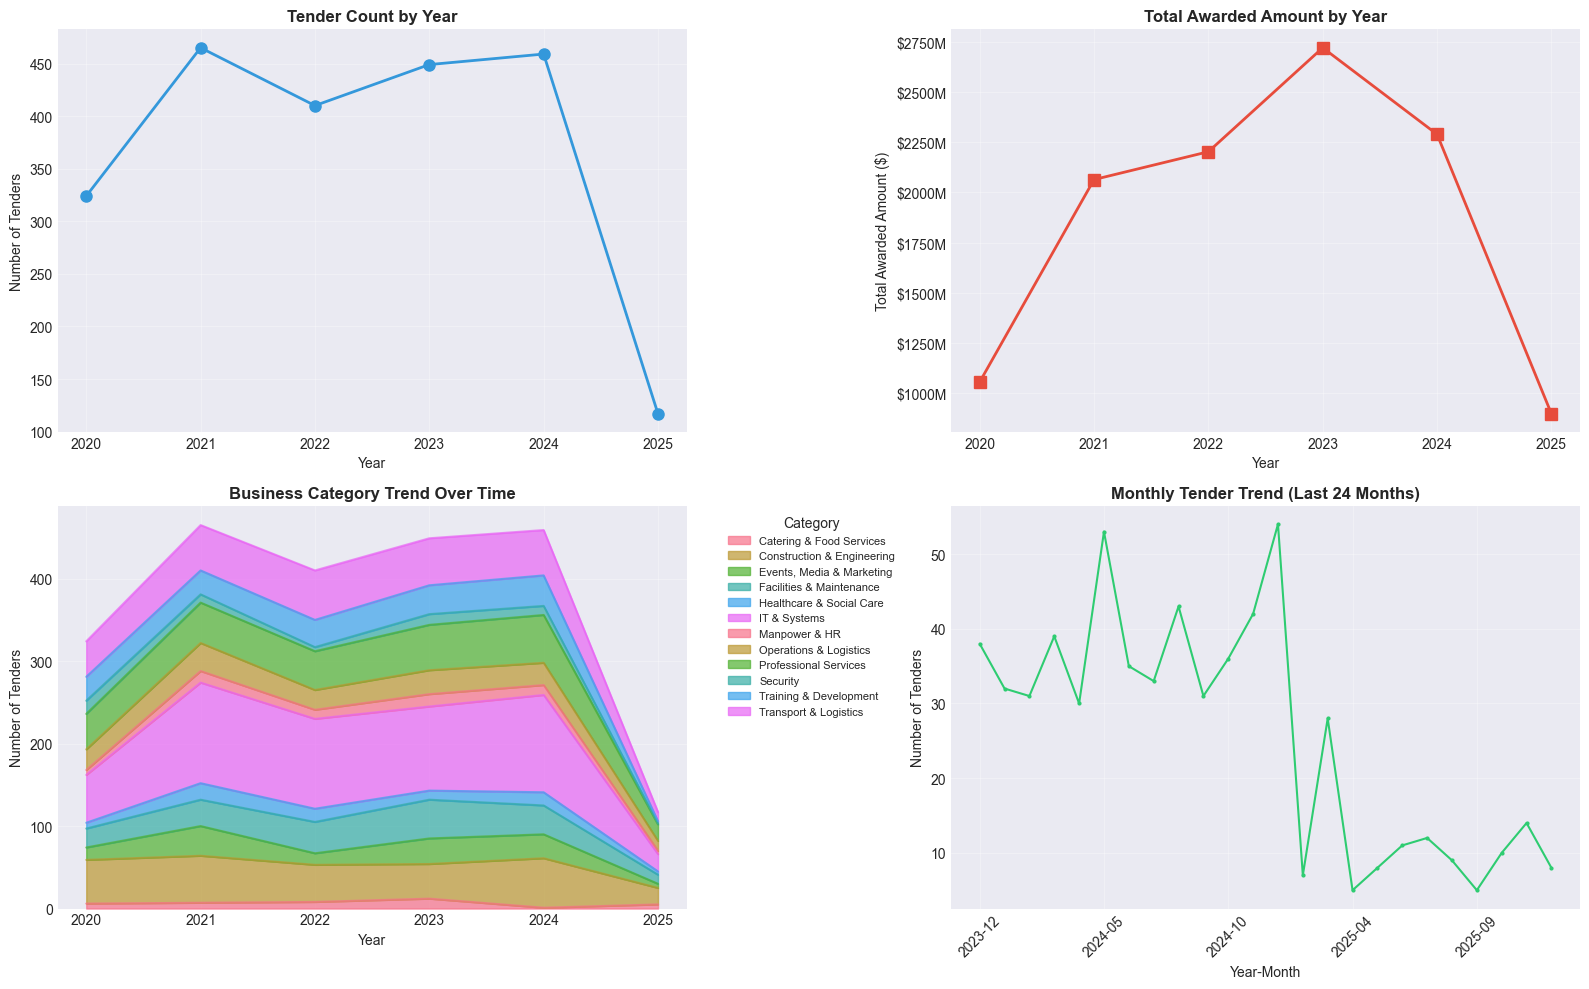


✓ Chart saved: time_trend_analysis.png


In [6]:
print(f"\n{'='*80}")
print("TIME TREND ANALYSIS")
print(f"{'='*80}\n")

# Yearly trends
yearly_trends = df_classified_tenders.groupby('award_year').agg({
    'tender_no': 'count',
    'awarded_amt': ['sum', 'mean']
}).round(2)

yearly_trends.columns = ['Tender Count', 'Total Value ($)', 'Average Value ($)']
print("YEARLY TRENDS:")
print(yearly_trends.to_string())

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Tender count by year
yearly_counts = df_classified_tenders.groupby('award_year')['tender_no'].count()
yearly_counts.plot(kind='line', ax=axes[0, 0], marker='o', color='#3498db', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Year', fontsize=10)
axes[0, 0].set_ylabel('Number of Tenders', fontsize=10)
axes[0, 0].set_title('Tender Count by Year', fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3)
axes[0, 0].set_xticks(yearly_counts.index)

# 2. Total awarded amount by year
yearly_value = df_classified_tenders.groupby('award_year')['awarded_amt'].sum()
yearly_value.plot(kind='line', ax=axes[0, 1], marker='s', color='#e74c3c', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('Year', fontsize=10)
axes[0, 1].set_ylabel('Total Awarded Amount ($)', fontsize=10)
axes[0, 1].set_title('Total Awarded Amount by Year', fontsize=12, fontweight='bold')
axes[0, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.0f}M'))
axes[0, 1].grid(alpha=0.3)
axes[0, 1].set_xticks(yearly_value.index)

# 3. Stacked area: Category trends by year
category_year = df_classified_tenders.groupby(['award_year', 'business_category']).size().unstack(fill_value=0)
category_year.plot(kind='area', ax=axes[1, 0], alpha=0.7)
axes[1, 0].set_xlabel('Year', fontsize=10)
axes[1, 0].set_ylabel('Number of Tenders', fontsize=10)
axes[1, 0].set_title('Business Category Trend Over Time', fontsize=12, fontweight='bold')
axes[1, 0].legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[1, 0].grid(alpha=0.3)

# 4. Monthly trend (aggregated)
monthly_counts = df_classified_tenders.groupby('year_month')['tender_no'].count().tail(24)  # Last 24 months
monthly_counts.plot(kind='line', ax=axes[1, 1], marker='.', color='#2ecc71', linewidth=1.5, markersize=4)
axes[1, 1].set_xlabel('Year-Month', fontsize=10)
axes[1, 1].set_ylabel('Number of Tenders', fontsize=10)
axes[1, 1].set_title('Monthly Tender Trend (Last 24 Months)', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(output_dir / 'time_trend_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Chart saved: time_trend_analysis.png")

## 6. Agency Analysis

Which government agencies spend the most and procure what?


AGENCY ANALYSIS

TOP 20 AGENCIES BY TOTAL AWARDED AMOUNT:
                                                                  Tender Count  Total Value ($)  Average Value ($)
agency                                                                                                            
Housing and Development Board                                              461     2.213741e+10        48020414.78
National Environment Agency                                                187     3.449472e+09        18446375.84
Land Transport Authority                                                   190     3.167793e+09        16672593.24
Ministry of Home Affairs - Ministry Headquarter 1                          228     2.643390e+09        11593816.67
Ministry of Education                                                      193     2.635984e+09        13657950.16
Public Utilities Board                                                     241     2.494664e+09        10351303.75
Ministry of Health-Mi

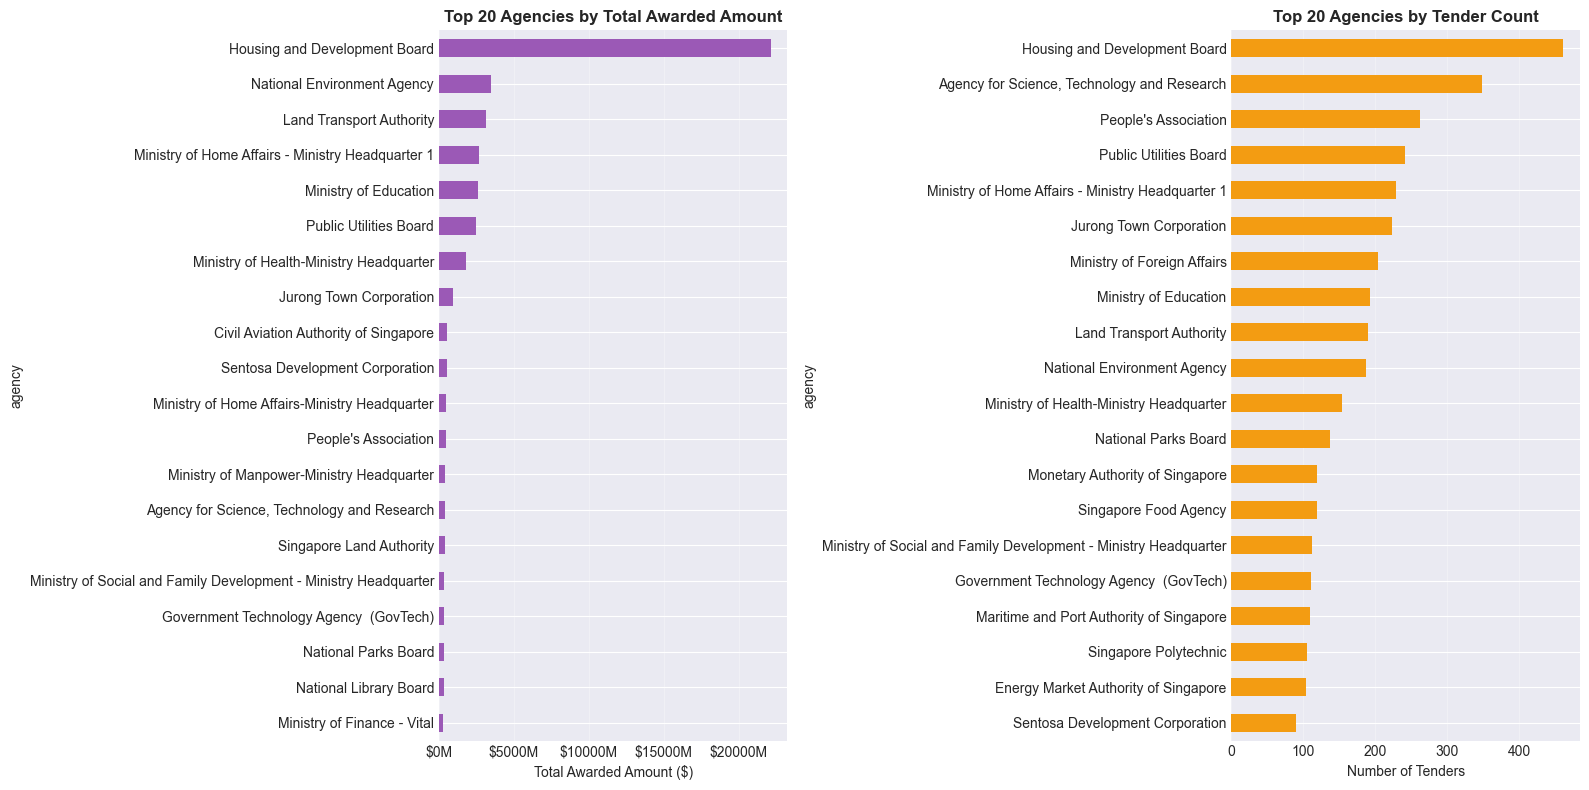


Chart saved: agency_analysis.png


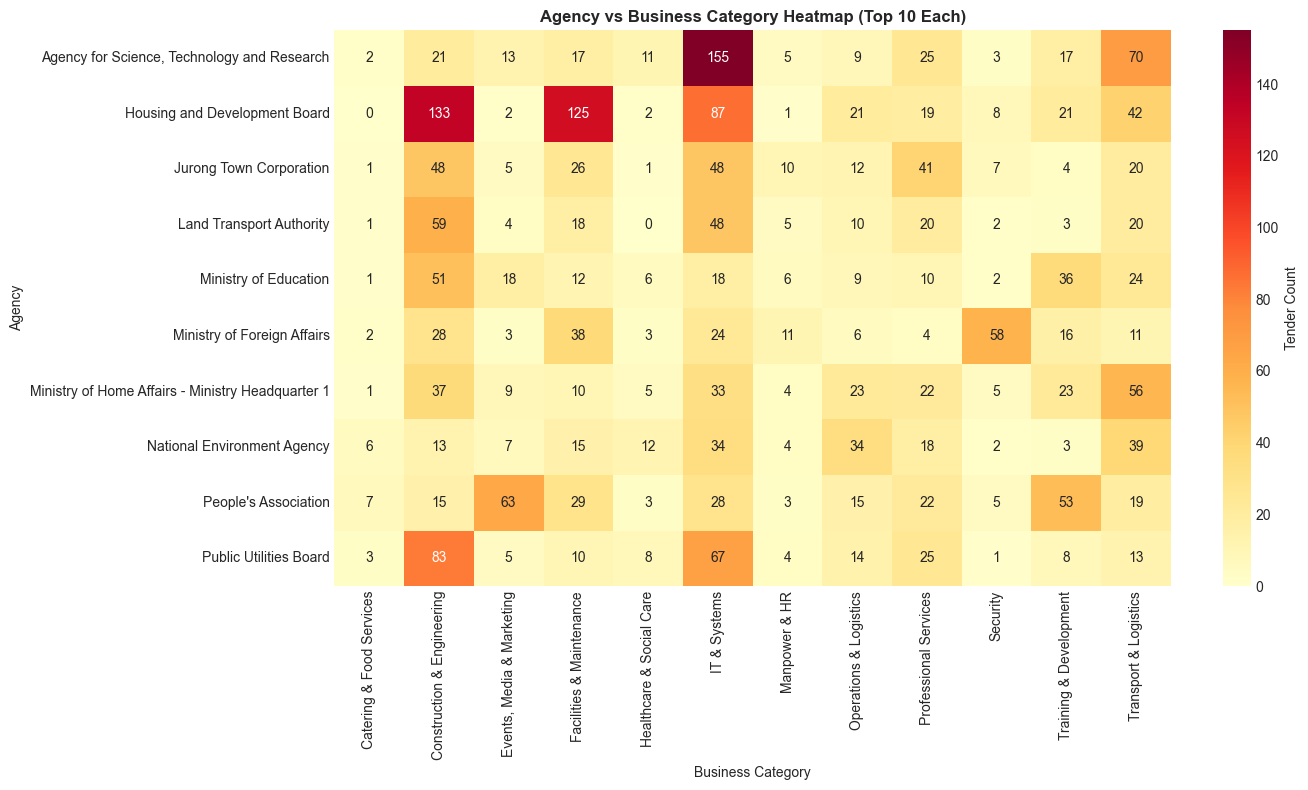

Chart saved: agency_category_heatmap.png


In [10]:
print(f"\n{'='*80}")
print("AGENCY ANALYSIS")
print(f"{'='*80}\n")

# Agency summary (tender-level)
agency_summary = df_classified_tenders.groupby('agency').agg({
    'tender_no': 'count',
    'awarded_amt': ['sum', 'mean']
}).round(2)

agency_summary.columns = ['Tender Count', 'Total Value ($)', 'Average Value ($)']
agency_summary = agency_summary.sort_values('Total Value ($)', ascending=False).head(20)

print("TOP 20 AGENCIES BY TOTAL AWARDED AMOUNT:")
print(agency_summary.to_string())

# Save agency summary
agency_summary.to_csv(output_dir / 'agency_summary.csv')
print(f"\n✓ Saved: agency_summary.csv")

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 1. Top 20 agencies by total value
top_20_value = df_classified_tenders.groupby('agency')['awarded_amt'].sum().nlargest(20).sort_values()
top_20_value.plot(kind='barh', ax=axes[0], color='#9b59b6')
axes[0].set_xlabel('Total Awarded Amount ($)', fontsize=10)
axes[0].set_title('Top 20 Agencies by Total Awarded Amount', fontsize=12, fontweight='bold')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.0f}M'))
axes[0].grid(axis='x', alpha=0.3)

# 2. Top 20 agencies by tender count
top_20_count = df_classified_tenders['agency'].value_counts().nlargest(20).sort_values()
top_20_count.plot(kind='barh', ax=axes[1], color='#f39c12')
axes[1].set_xlabel('Number of Tenders', fontsize=10)
axes[1].set_title('Top 20 Agencies by Tender Count', fontsize=12, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / 'agency_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nChart saved: agency_analysis.png")

# Agency vs Category heatmap (top 10 agencies and categories)
top_agencies = df_classified_tenders['agency'].value_counts().head(10).index
top_categories = df_classified_tenders['business_category'].value_counts().head(10).index

heatmap_data = df_classified_tenders[df_classified_tenders['agency'].isin(top_agencies)].groupby(
    ['agency', 'business_category']
).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Tender Count'})
ax.set_title('Agency vs Business Category Heatmap (Top 10 Each)', fontsize=12, fontweight='bold')
ax.set_xlabel('Business Category', fontsize=10)
ax.set_ylabel('Agency', fontsize=10)
plt.tight_layout()
plt.savefig(output_dir / 'agency_category_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Chart saved: agency_category_heatmap.png")

## 7. Supplier Analysis

Which suppliers win the most contracts? 
**Note**: Row-level data is used here since suppliers can win multiple times per tender.


SUPPLIER ANALYSIS

Note: Using row-level data (suppliers can appear multiple times per tender)

TOP 20 SUPPLIERS BY TOTAL AWARDED AMOUNT:
                                                                         Award Count  Total Value ($)  Average Value ($)
supplier_name                                                                                                           
KAY LIM CONSTRUCTION & TRADING PTE LTD                                             7     1.522800e+09       2.175429e+08
KEPPEL SEGHERS ENGINEERING SINGAPORE PTE. LTD.                                     1     1.493179e+09       1.493179e+09
TEAMBUILD ENGINEERING & CONSTRUCTION PTE. LTD.                                     5     1.437235e+09       2.874470e+08
WELLTECH CONSTRUCTION PTE LTD                                                      5     1.294000e+09       2.588000e+08
CES ENGINEERING & CONSTRUCTION PTE. LTD.                                           3     1.190180e+09       3.967267e+08
NEWCON BUILDER

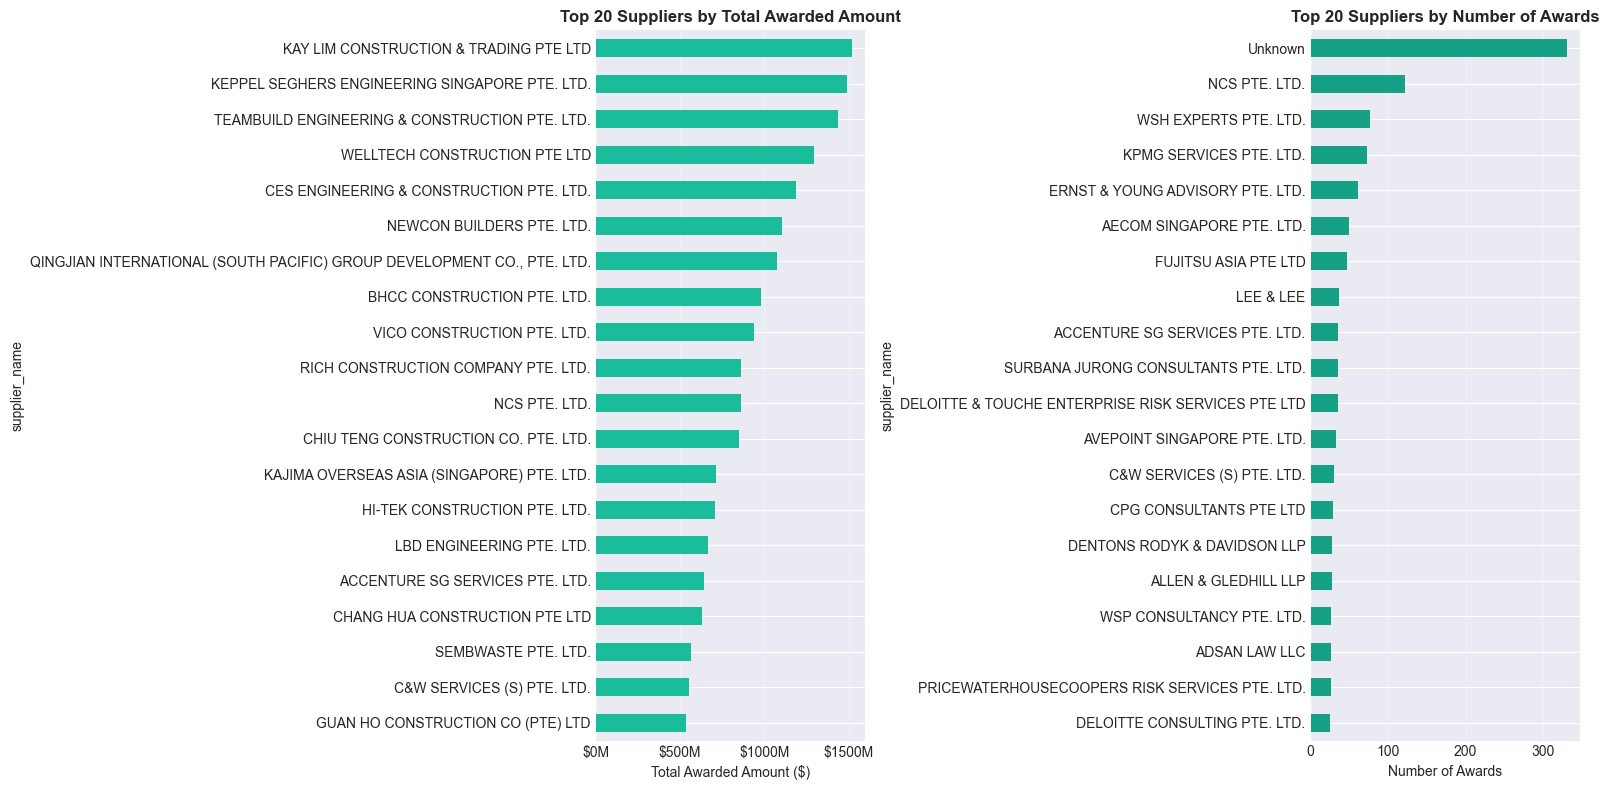


✓ Chart saved: supplier_analysis.png


In [8]:
print(f"\n{'='*80}")
print("SUPPLIER ANALYSIS")
print(f"{'='*80}\n")
print(f"Note: Using row-level data (suppliers can appear multiple times per tender)\n")

# Supplier summary (row-level)
supplier_summary = df_classified.groupby('supplier_name').agg({
    'tender_no': 'count',
    'awarded_amt': ['sum', 'mean']
}).round(2)

supplier_summary.columns = ['Award Count', 'Total Value ($)', 'Average Value ($)']
supplier_summary = supplier_summary.sort_values('Total Value ($)', ascending=False).head(20)

print("TOP 20 SUPPLIERS BY TOTAL AWARDED AMOUNT:")
print(supplier_summary.to_string())

# Save supplier summary
supplier_summary.to_csv(output_dir / 'supplier_summary.csv')
print(f"\n✓ Saved: supplier_summary.csv")
print(f"\n⚠️  Note: Supplier names may need normalization (e.g., 'ABC Corp' vs 'ABC CORP'). This is exploratory.")

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 1. Top 20 suppliers by total value
top_20_supp_value = df_classified.groupby('supplier_name')['awarded_amt'].sum().nlargest(20).sort_values()
top_20_supp_value.plot(kind='barh', ax=axes[0], color='#1abc9c')
axes[0].set_xlabel('Total Awarded Amount ($)', fontsize=10)
axes[0].set_title('Top 20 Suppliers by Total Awarded Amount', fontsize=12, fontweight='bold')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.0f}M'))
axes[0].grid(axis='x', alpha=0.3)

# 2. Top 20 suppliers by award count
top_20_supp_count = df_classified['supplier_name'].value_counts().nlargest(20).sort_values()
top_20_supp_count.plot(kind='barh', ax=axes[1], color='#16a085')
axes[1].set_xlabel('Number of Awards', fontsize=10)
axes[1].set_title('Top 20 Suppliers by Number of Awards', fontsize=12, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / 'supplier_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Chart saved: supplier_analysis.png")

## 8. Procurement Type Analysis

Understanding how government procures: Provision vs Maintenance vs Consultancy, etc.


PROCUREMENT TYPE ANALYSIS

PROCUREMENT TYPE SUMMARY:
                  Tender Count  Total Value ($)  Average Value ($)
procurement_type                                                  
Contract                   345     2.383396e+10        69083954.08
Provision                 3856     1.397979e+10         3625463.07
Other                      731     7.843081e+09        10729248.95
Maintenance                581     3.003451e+09         5169451.65
Consultancy                450     6.291632e+08         1398140.46
Procurement                 59     2.604513e+08         4414428.50
Support                     94     2.225827e+08         2367901.31
Implementation              23     8.790009e+07         3821742.88
Outsourcing                  6     1.201914e+07         2003189.52


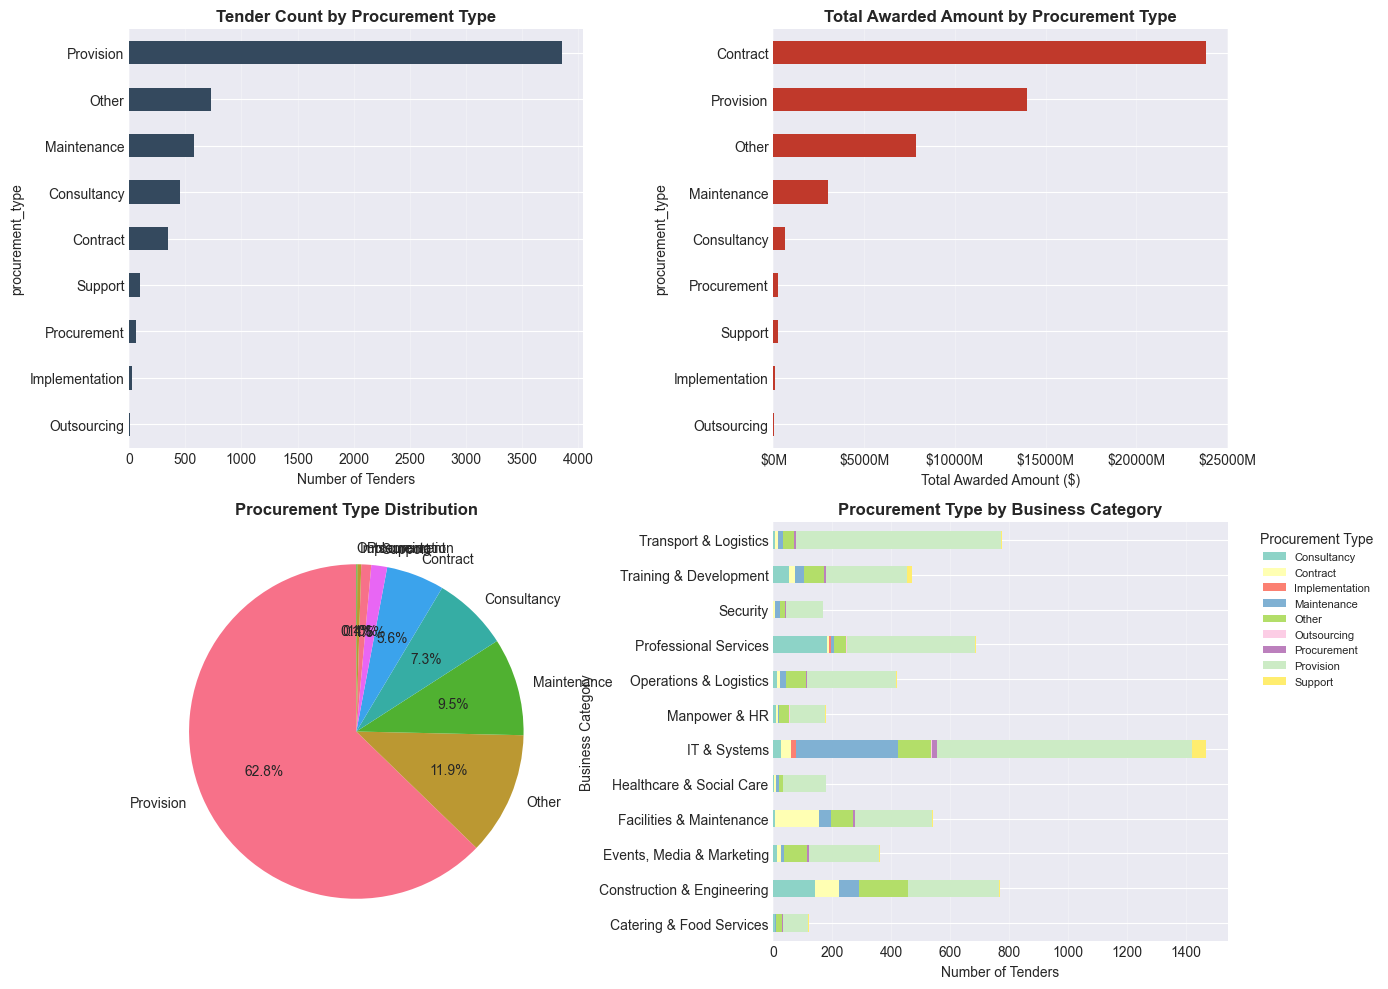


✓ Chart saved: procurement_type_analysis.png


In [9]:
print(f"\n{'='*80}")
print("PROCUREMENT TYPE ANALYSIS")
print(f"{'='*80}\n")

# Procurement type summary
ptype_summary = df_classified_tenders.groupby('procurement_type').agg({
    'tender_no': 'count',
    'awarded_amt': ['sum', 'mean']
}).round(2)

ptype_summary.columns = ['Tender Count', 'Total Value ($)', 'Average Value ($)']
ptype_summary = ptype_summary.sort_values('Total Value ($)', ascending=False)

print("PROCUREMENT TYPE SUMMARY:")
print(ptype_summary.to_string())

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Tender count by procurement type
ptype_counts = df_classified_tenders['procurement_type'].value_counts().sort_values()
ptype_counts.plot(kind='barh', ax=axes[0, 0], color='#34495e')
axes[0, 0].set_xlabel('Number of Tenders', fontsize=10)
axes[0, 0].set_title('Tender Count by Procurement Type', fontsize=12, fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3)

# 2. Total value by procurement type
ptype_value = df_classified_tenders.groupby('procurement_type')['awarded_amt'].sum().sort_values()
ptype_value.plot(kind='barh', ax=axes[0, 1], color='#c0392b')
axes[0, 1].set_xlabel('Total Awarded Amount ($)', fontsize=10)
axes[0, 1].set_title('Total Awarded Amount by Procurement Type', fontsize=12, fontweight='bold')
axes[0, 1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.0f}M'))
axes[0, 1].grid(axis='x', alpha=0.3)

# 3. Procurement type distribution pie
ptype_pie = df_classified_tenders['procurement_type'].value_counts()
axes[1, 0].pie(ptype_pie.values, labels=ptype_pie.index, autopct='%1.1f%%', startangle=90)
axes[1, 0].set_title('Procurement Type Distribution', fontsize=12, fontweight='bold')

# 4. Procurement type by business category (stacked)
ptype_category = pd.crosstab(df_classified_tenders['business_category'], df_classified_tenders['procurement_type'])
ptype_category.plot(kind='barh', stacked=True, ax=axes[1, 1], colormap='Set3')
axes[1, 1].set_xlabel('Number of Tenders', fontsize=10)
axes[1, 1].set_ylabel('Business Category', fontsize=10)
axes[1, 1].set_title('Procurement Type by Business Category', fontsize=12, fontweight='bold')
axes[1, 1].legend(title='Procurement Type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / 'procurement_type_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Chart saved: procurement_type_analysis.png")

## 9. Recurring Services Analysis

Which categories have recurring/ongoing services? These are important for capacity planning.


RECURRING SERVICES ANALYSIS

OVERALL RECURRING STATUS:
  Recurring: 5,214 (84.8%)
  Non-recurring: 931 (15.2%)

RECURRING BY BUSINESS CATEGORY:
recurring_service_label     Non-recurring  Recurring  % Recurring
business_category                                                
Operations & Logistics                 17        403         96.0
Security                                7        161         95.8
Construction & Engineering             70        701         90.9
Facilities & Maintenance               58        485         89.3
Healthcare & Social Care               26        153         85.5
Events, Media & Marketing              53        309         85.4
Professional Services                 104        585         84.9
Transport & Logistics                 131        646         83.1
IT & Systems                          254       1215         82.7
Catering & Food Services               23         97         80.8
Manpower & HR                          38        139         78

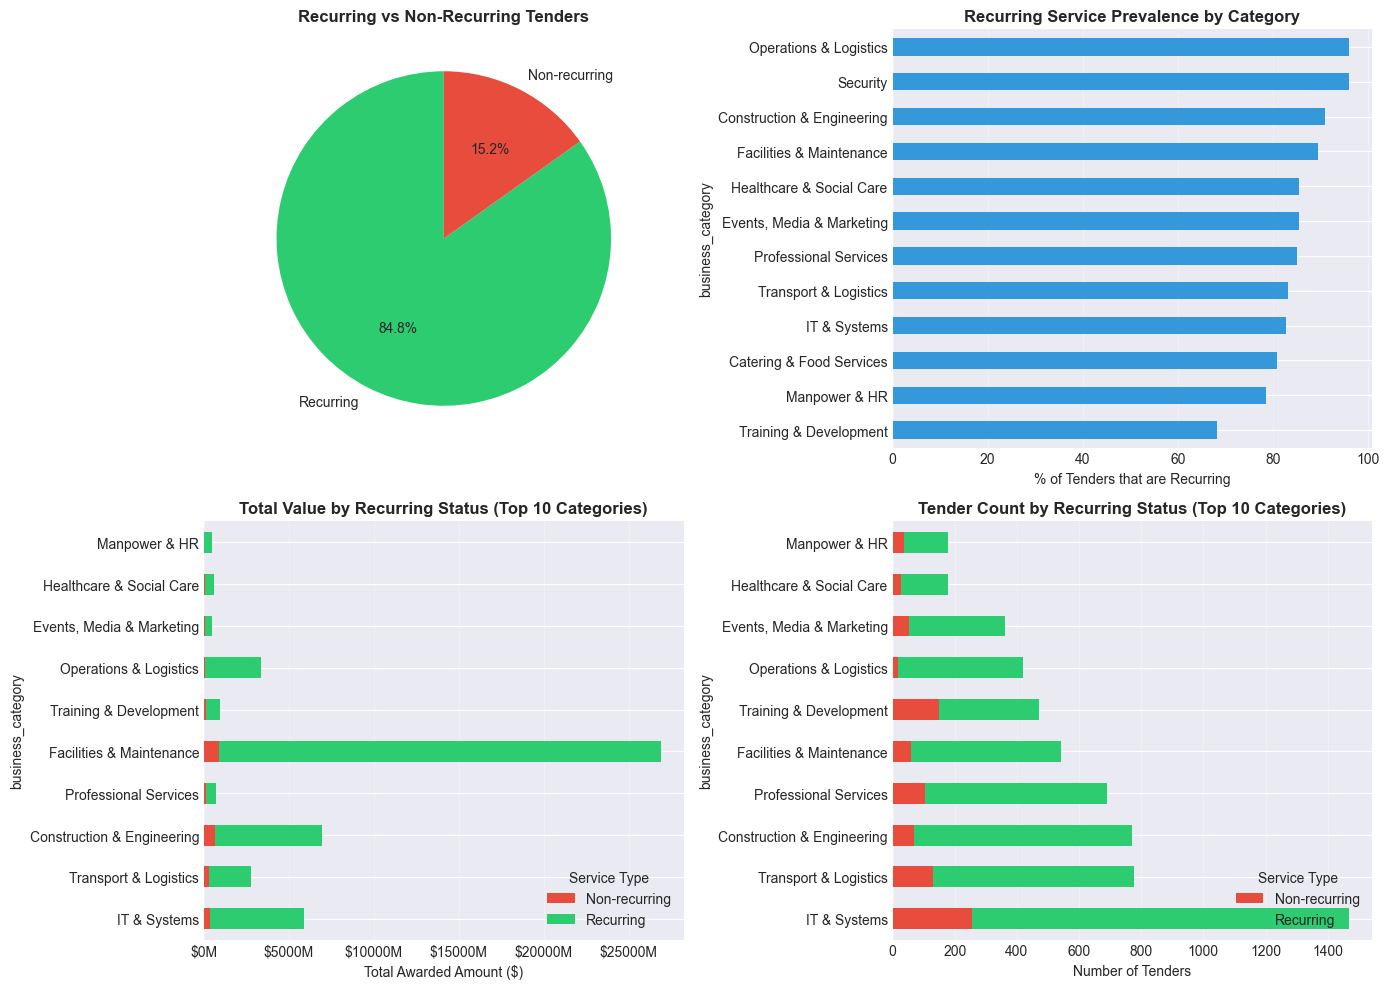


✓ Chart saved: recurring_services_analysis.png


In [11]:
print(f"\n{'='*80}")
print("RECURRING SERVICES ANALYSIS")
print(f"{'='*80}\n")

# Overall recurring vs non-recurring
recurring_counts = df_classified_tenders['recurring_service_label'].value_counts()
print(f"OVERALL RECURRING STATUS:")
for label, count in recurring_counts.items():
    pct = count / len(df_classified_tenders) * 100
    print(f"  {label}: {count:,} ({pct:.1f}%)")

# Recurring by category
print(f"\nRECURRING BY BUSINESS CATEGORY:")
recurring_by_cat = pd.crosstab(
    df_classified_tenders['business_category'],
    df_classified_tenders['recurring_service_label'],
    margins=False
)
recurring_by_cat['% Recurring'] = (recurring_by_cat['Recurring'] / 
                                   (recurring_by_cat['Recurring'] + recurring_by_cat['Non-recurring']) * 100).round(1)
print(recurring_by_cat.sort_values('% Recurring', ascending=False).to_string())

# Value analysis for recurring
print(f"\nRECURRING VALUE ANALYSIS:")
recurring_value = df_classified_tenders.groupby('recurring_service_label')['awarded_amt'].agg(['sum', 'mean', 'count'])
recurring_value.columns = ['Total Value ($)', 'Average Value ($)', 'Count']
print(recurring_value.round(2).to_string())

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Recurring vs non-recurring pie
recurring_pie = df_classified_tenders['recurring_service_label'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0, 0].pie(recurring_pie.values, labels=recurring_pie.index, autopct='%1.1f%%', colors=colors, startangle=90)
axes[0, 0].set_title('Recurring vs Non-Recurring Tenders', fontsize=12, fontweight='bold')

# 2. Recurring by category
recurring_by_cat_pct = pd.crosstab(
    df_classified_tenders['business_category'],
    df_classified_tenders['recurring_service']
, normalize='index') * 100
recurring_by_cat_pct[True].sort_values().plot(kind='barh', ax=axes[0, 1], color='#3498db')
axes[0, 1].set_xlabel('% of Tenders that are Recurring', fontsize=10)
axes[0, 1].set_title('Recurring Service Prevalence by Category', fontsize=12, fontweight='bold')
axes[0, 1].grid(axis='x', alpha=0.3)

# 3. Total value: recurring vs non-recurring
recurring_value_by_cat = df_classified_tenders.groupby(['business_category', 'recurring_service_label'])['awarded_amt'].sum().unstack()
recurring_value_by_cat = recurring_value_by_cat.loc[df_classified_tenders['business_category'].value_counts().head(10).index]
recurring_value_by_cat.plot(kind='barh', stacked=True, ax=axes[1, 0], color=['#e74c3c', '#2ecc71'])
axes[1, 0].set_xlabel('Total Awarded Amount ($)', fontsize=10)
axes[1, 0].set_title('Total Value by Recurring Status (Top 10 Categories)', fontsize=12, fontweight='bold')
axes[1, 0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.0f}M'))
axes[1, 0].legend(title='Service Type', loc='lower right')
axes[1, 0].grid(axis='x', alpha=0.3)

# 4. Tender count by recurring and category
recurring_count_by_cat = df_classified_tenders.groupby(['business_category', 'recurring_service_label'])['tender_no'].count().unstack()
recurring_count_by_cat = recurring_count_by_cat.loc[df_classified_tenders['business_category'].value_counts().head(10).index]
recurring_count_by_cat.plot(kind='barh', stacked=True, ax=axes[1, 1], color=['#e74c3c', '#2ecc71'])
axes[1, 1].set_xlabel('Number of Tenders', fontsize=10)
axes[1, 1].set_title('Tender Count by Recurring Status (Top 10 Categories)', fontsize=12, fontweight='bold')
axes[1, 1].legend(title='Service Type', loc='lower right')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / 'recurring_services_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Chart saved: recurring_services_analysis.png")

## 10. Manpower-Heavy Analysis

Which categories require significant staffing? Useful for HR and workforce planning.


MANPOWER-HEAVY ANALYSIS

OVERALL MANPOWER STATUS:
  Not manpower-heavy: 4,753 (77.3%)
  Manpower-heavy: 1,392 (22.7%)

MANPOWER-HEAVY BY BUSINESS CATEGORY:
manpower_heavy_label        Manpower-heavy  Not manpower-heavy  % Manpower-Heavy
business_category                                                               
Manpower & HR                          155                  22              87.6
Training & Development                 247                 223              52.6
Professional Services                  317                 372              46.0
Construction & Engineering             277                 494              35.9
Healthcare & Social Care                35                 144              19.6
Catering & Food Services                17                 103              14.2
Transport & Logistics                  100                 677              12.9
Operations & Logistics                  40                 380               9.5
IT & Systems                     

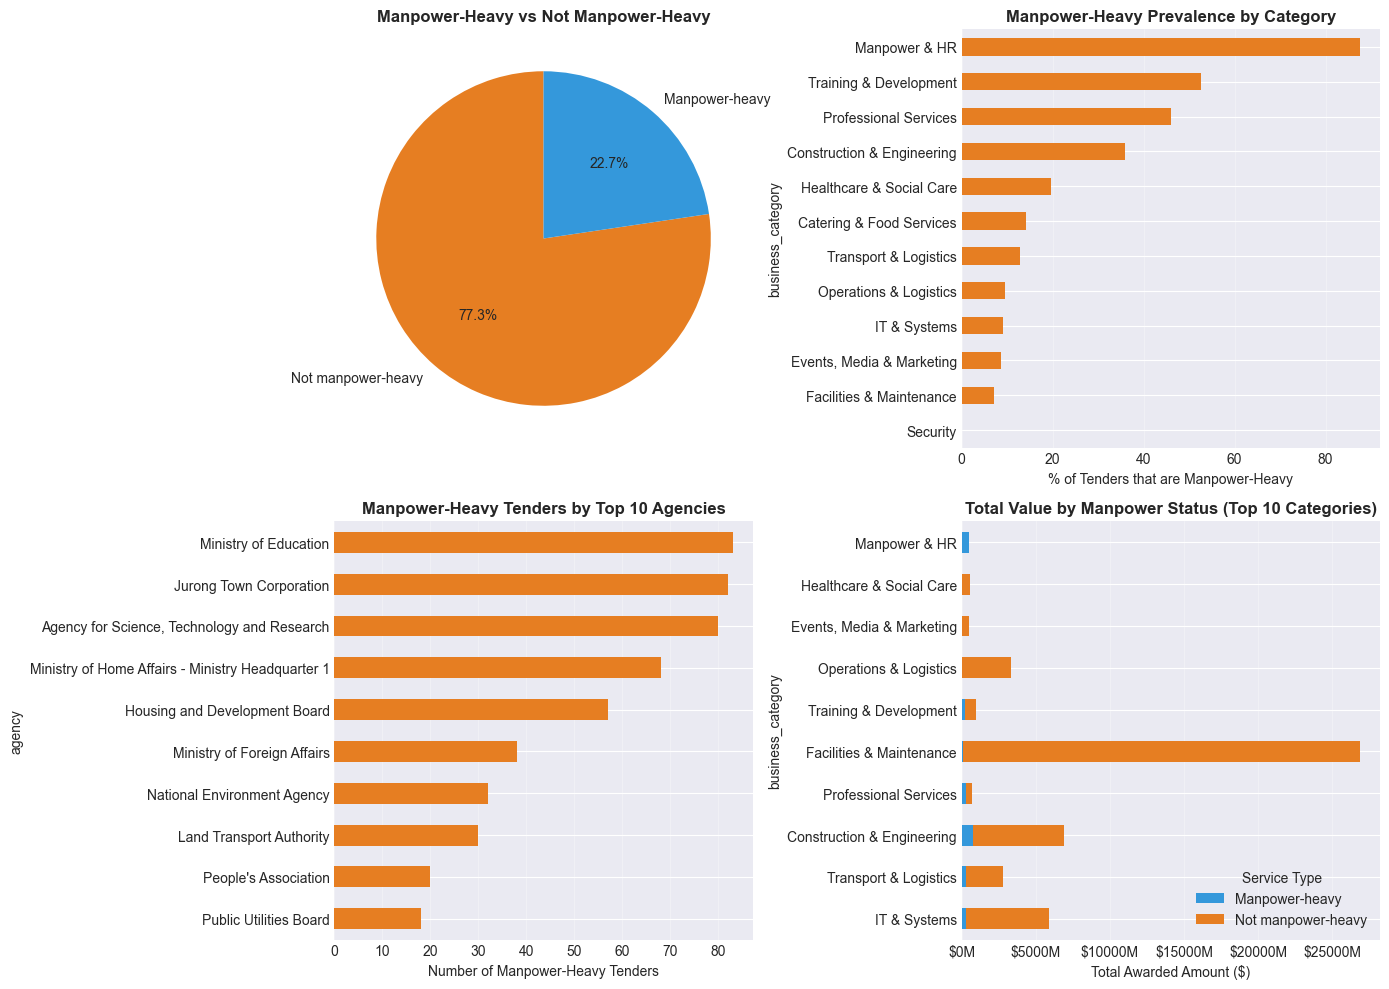


✓ Chart saved: manpower_heavy_analysis.png


In [12]:
print(f"\n{'='*80}")
print("MANPOWER-HEAVY ANALYSIS")
print(f"{'='*80}\n")

# Overall manpower status
manpower_counts = df_classified_tenders['manpower_heavy_label'].value_counts()
print(f"OVERALL MANPOWER STATUS:")
for label, count in manpower_counts.items():
    pct = count / len(df_classified_tenders) * 100
    print(f"  {label}: {count:,} ({pct:.1f}%)")

# Manpower by category
print(f"\nMANPOWER-HEAVY BY BUSINESS CATEGORY:")
manpower_by_cat = pd.crosstab(
    df_classified_tenders['business_category'],
    df_classified_tenders['manpower_heavy_label'],
    margins=False
)
manpower_by_cat['% Manpower-Heavy'] = (manpower_by_cat['Manpower-heavy'] / 
                                       (manpower_by_cat['Manpower-heavy'] + manpower_by_cat['Not manpower-heavy']) * 100).round(1)
print(manpower_by_cat.sort_values('% Manpower-Heavy', ascending=False).to_string())

# Value analysis for manpower
print(f"\nMANPOWER-HEAVY VALUE ANALYSIS:")
manpower_value = df_classified_tenders.groupby('manpower_heavy_label')['awarded_amt'].agg(['sum', 'mean', 'count'])
manpower_value.columns = ['Total Value ($)', 'Average Value ($)', 'Count']
print(manpower_value.round(2).to_string())

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Manpower-heavy vs not pie
manpower_pie = df_classified_tenders['manpower_heavy_label'].value_counts()
colors = ['#e67e22', '#3498db']
axes[0, 0].pie(manpower_pie.values, labels=manpower_pie.index, autopct='%1.1f%%', colors=colors, startangle=90)
axes[0, 0].set_title('Manpower-Heavy vs Not Manpower-Heavy', fontsize=12, fontweight='bold')

# 2. Manpower by category
manpower_by_cat_pct = pd.crosstab(
    df_classified_tenders['business_category'],
    df_classified_tenders['manpower_heavy']
, normalize='index') * 100
manpower_by_cat_pct[True].sort_values().plot(kind='barh', ax=axes[0, 1], color='#e67e22')
axes[0, 1].set_xlabel('% of Tenders that are Manpower-Heavy', fontsize=10)
axes[0, 1].set_title('Manpower-Heavy Prevalence by Category', fontsize=12, fontweight='bold')
axes[0, 1].grid(axis='x', alpha=0.3)

# 3. Manpower by agency (top 10 agencies)
top_agencies_list = df_classified_tenders['agency'].value_counts().head(10).index
manpower_by_agency = df_classified_tenders[df_classified_tenders['agency'].isin(top_agencies_list)].groupby('agency')['manpower_heavy'].apply(lambda x: (x==True).sum())
manpower_by_agency = manpower_by_agency.sort_values()
manpower_by_agency.plot(kind='barh', ax=axes[1, 0], color='#e67e22')
axes[1, 0].set_xlabel('Number of Manpower-Heavy Tenders', fontsize=10)
axes[1, 0].set_title('Manpower-Heavy Tenders by Top 10 Agencies', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='x', alpha=0.3)

# 4. Total value by manpower status
manpower_value_by_cat = df_classified_tenders.groupby(['business_category', 'manpower_heavy_label'])['awarded_amt'].sum().unstack()
manpower_value_by_cat = manpower_value_by_cat.loc[df_classified_tenders['business_category'].value_counts().head(10).index]
manpower_value_by_cat.plot(kind='barh', stacked=True, ax=axes[1, 1], color=['#3498db', '#e67e22'])
axes[1, 1].set_xlabel('Total Awarded Amount ($)', fontsize=10)
axes[1, 1].set_title('Total Value by Manpower Status (Top 10 Categories)', fontsize=12, fontweight='bold')
axes[1, 1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.0f}M'))
axes[1, 1].legend(title='Service Type', loc='lower right')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / 'manpower_heavy_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Chart saved: manpower_heavy_analysis.png")

## 11. Budget Bucket Analysis

Understanding the distribution of contract sizes: small, medium, large, mega.


BUDGET BUCKET ANALYSIS

BUDGET BUCKET DISTRIBUTION (all data including unclassified):
  Unknown / $0: 441 (3.5%)
  Small (<$100k): 5,017 (39.9%)
  Medium ($100k-$1M): 4,243 (33.7%)
  Large ($1M-$10M): 2,181 (17.3%)
  Mega (>$10M): 690 (5.5%)

BUDGET BUCKET DISTRIBUTION (classified only):
  Unknown / $0: 331 (3.5%)
  Small (<$100k): 3,679 (38.5%)
  Medium ($100k-$1M): 3,253 (34.0%)
  Large ($1M-$10M): 1,723 (18.0%)
  Mega (>$10M): 568 (5.9%)

BUDGET BUCKET BY BUSINESS CATEGORY (top 8 categories):
budget_bucket               Large ($1M-$10M)  Medium ($100k-$1M)  Mega (>$10M)  Small (<$100k)  Unknown / $0
business_category                                                                                           
Construction & Engineering               230                 287            92             258            37
Events, Media & Marketing                 90                 253             2             600            18
Facilities & Maintenance                 142                 1

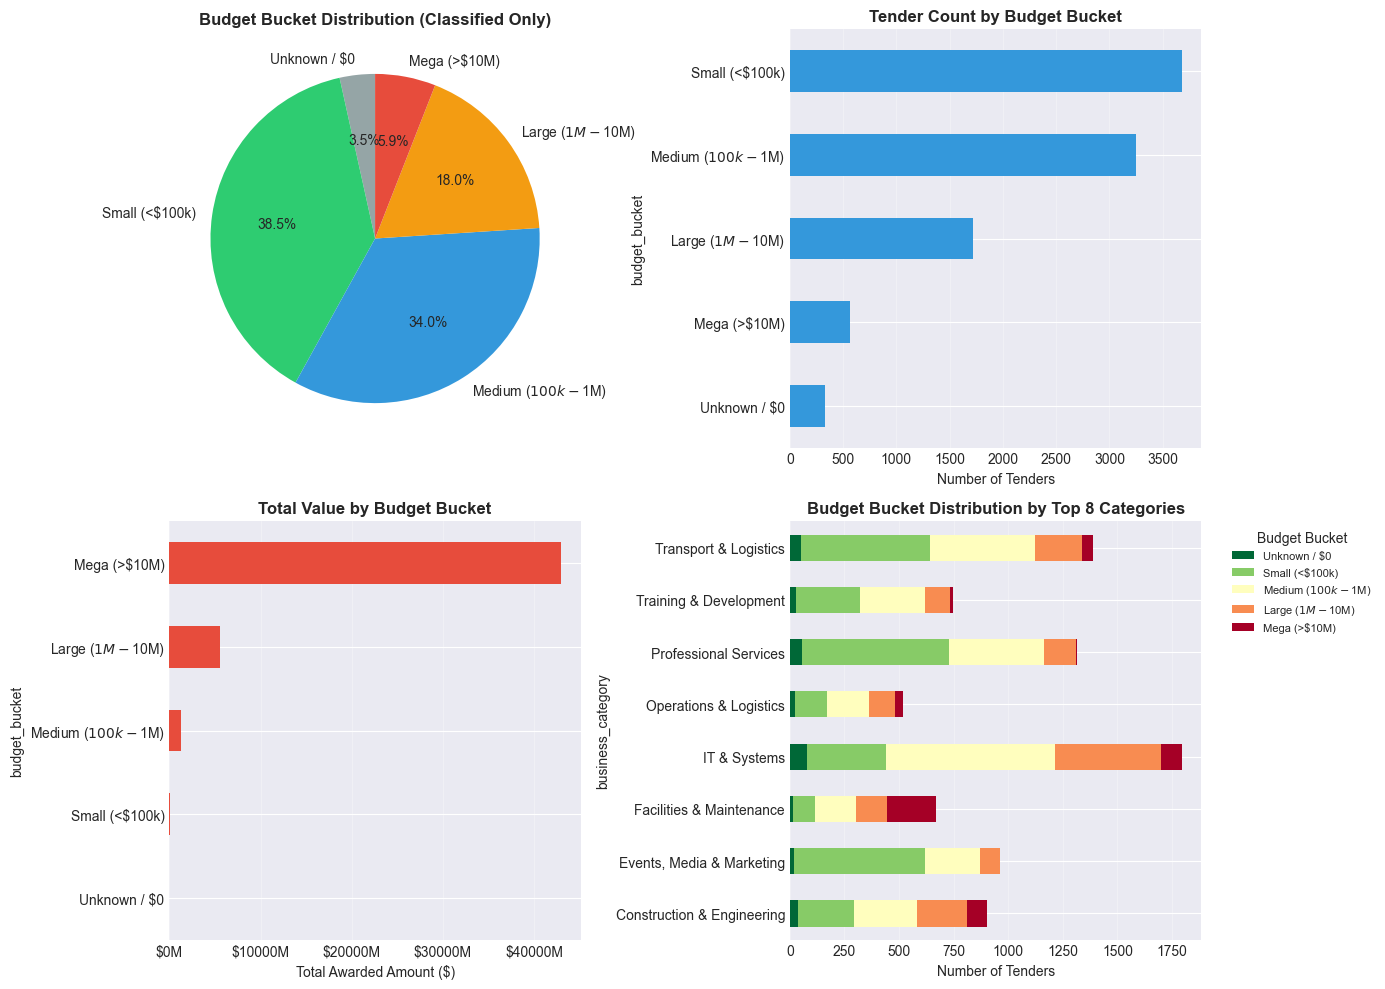


✓ Chart saved: budget_bucket_analysis.png


In [13]:
print(f"\n{'='*80}")
print("BUDGET BUCKET ANALYSIS")
print(f"{'='*80}\n")

# Budget bucket breakdown
budget_order = ['Unknown / $0', 'Small (<$100k)', 'Medium ($100k-$1M)', 'Large ($1M-$10M)', 'Mega (>$10M)']
budget_breakdown = df['budget_bucket'].value_counts().reindex(budget_order, fill_value=0)

print(f"BUDGET BUCKET DISTRIBUTION (all data including unclassified):")
for bucket, count in budget_breakdown.items():
    pct = count / len(df) * 100
    print(f"  {bucket}: {count:,} ({pct:.1f}%)")

# Budget breakdown for classified only
budget_classified = df_classified['budget_bucket'].value_counts().reindex(budget_order, fill_value=0)
print(f"\nBUDGET BUCKET DISTRIBUTION (classified only):")
for bucket, count in budget_classified.items():
    pct = count / len(df_classified) * 100
    print(f"  {bucket}: {count:,} ({pct:.1f}%)")

# Budget by category
print(f"\nBUDGET BUCKET BY BUSINESS CATEGORY (top 8 categories):")
top_cats = df_classified['business_category'].value_counts().head(8).index
budget_by_cat = pd.crosstab(df_classified[df_classified['business_category'].isin(top_cats)]['business_category'],
                             df_classified[df_classified['business_category'].isin(top_cats)]['budget_bucket'])
print(budget_by_cat.to_string())

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Budget bucket distribution pie (classified)
budget_pie = df_classified['budget_bucket'].value_counts().reindex(budget_order, fill_value=0)
colors_budget = ['#95a5a6', '#2ecc71', '#3498db', '#f39c12', '#e74c3c']
axes[0, 0].pie(budget_pie.values, labels=budget_pie.index, autopct='%1.1f%%', colors=colors_budget, startangle=90)
axes[0, 0].set_title('Budget Bucket Distribution (Classified Only)', fontsize=12, fontweight='bold')

# 2. Tender count by budget bucket
budget_count = df_classified['budget_bucket'].value_counts().reindex(budget_order, fill_value=0).sort_values()
budget_count.plot(kind='barh', ax=axes[0, 1], color='#3498db')
axes[0, 1].set_xlabel('Number of Tenders', fontsize=10)
axes[0, 1].set_title('Tender Count by Budget Bucket', fontsize=12, fontweight='bold')
axes[0, 1].grid(axis='x', alpha=0.3)

# 3. Total value by budget bucket
budget_value = df_classified.groupby('budget_bucket')['awarded_amt'].sum().reindex(budget_order, fill_value=0).sort_values()
budget_value.plot(kind='barh', ax=axes[1, 0], color='#e74c3c')
axes[1, 0].set_xlabel('Total Awarded Amount ($)', fontsize=10)
axes[1, 0].set_title('Total Value by Budget Bucket', fontsize=12, fontweight='bold')
axes[1, 0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.0f}M'))
axes[1, 0].grid(axis='x', alpha=0.3)

# 4. Budget distribution by top 8 categories (stacked)
budget_by_cat_stacked = pd.crosstab(df_classified[df_classified['business_category'].isin(top_cats)]['business_category'],
                                     df_classified[df_classified['business_category'].isin(top_cats)]['budget_bucket'])
budget_by_cat_stacked = budget_by_cat_stacked[budget_order]
budget_by_cat_stacked.plot(kind='barh', stacked=True, ax=axes[1, 1], colormap='RdYlGn_r')
axes[1, 1].set_xlabel('Number of Tenders', fontsize=10)
axes[1, 1].set_title('Budget Bucket Distribution by Top 8 Categories', fontsize=12, fontweight='bold')
axes[1, 1].legend(title='Budget Bucket', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / 'budget_bucket_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Chart saved: budget_bucket_analysis.png")

## 12. Export Analysis-Ready Datasets

Save cleaned data and summary tables for further use.

In [14]:
print(f"\n{'='*80}")
print("EXPORTING DATASETS")
print(f"{'='*80}\n")

# 1. Row-level visualisation data
output_file_row = output_dir / 'GPGB_visualisation_row_level.csv'
df.to_csv(output_file_row, index=False)
print(f"✓ Exported row-level data:")
print(f"  File: GPGB_visualisation_row_level.csv")
print(f"  Rows: {len(df):,}")
print(f"  Columns: {len(df.columns)}")

# 2. Tender-level visualisation data
output_file_tender = output_dir / 'GPGB_visualisation_tender_level.csv'
df_tender_level.to_csv(output_file_tender, index=False)
print(f"\n✓ Exported tender-level data:")
print(f"  File: GPGB_visualisation_tender_level.csv")
print(f"  Rows (unique tenders): {len(df_tender_level):,}")
print(f"  Columns: {len(df_tender_level.columns)}")

# 3. Category summary (already saved, confirm)
print(f"\n✓ Exported category_summary.csv")
print(f"  Rows: {len(category_summary)}")

# 4. Agency summary (already saved, confirm)
print(f"\n✓ Exported agency_summary.csv")
print(f"  Rows: {len(agency_summary)}")

# 5. Supplier summary (already saved, confirm)
print(f"\n✓ Exported supplier_summary.csv")
print(f"  Rows: {len(supplier_summary)}")

print(f"\n{'='*80}")
print(f"ALL EXPORTS COMPLETE")
print(f"{'='*80}")
print(f"\nOutput directory: {output_dir}")
print(f"\nFiles created:")
print(f"  - GPGB_visualisation_row_level.csv")
print(f"  - GPGB_visualisation_tender_level.csv")
print(f"  - category_summary.csv")
print(f"  - agency_summary.csv")
print(f"  - supplier_summary.csv")
print(f"  - 8 PNG charts (quality overview, category analysis, trends, agency, supplier, procurement type, recurring, manpower, budget)")


EXPORTING DATASETS

✓ Exported row-level data:
  File: GPGB_visualisation_row_level.csv
  Rows: 12,572
  Columns: 18

✓ Exported tender-level data:
  File: GPGB_visualisation_tender_level.csv
  Rows (unique tenders): 7,921
  Columns: 18

✓ Exported category_summary.csv
  Rows: 12

✓ Exported agency_summary.csv
  Rows: 20

✓ Exported supplier_summary.csv
  Rows: 20

ALL EXPORTS COMPLETE

Output directory: Dataset\Visualisation

Files created:
  - GPGB_visualisation_row_level.csv
  - GPGB_visualisation_tender_level.csv
  - category_summary.csv
  - agency_summary.csv
  - supplier_summary.csv
  - 8 PNG charts (quality overview, category analysis, trends, agency, supplier, procurement type, recurring, manpower, budget)


## 13. Key Insights Summary

Automatic plain-English summary of findings.

In [15]:
print(f"\n\n{'='*80}")
print(" " * 20 + "KEY INSIGHTS SUMMARY")
print(f"{'='*80}\n")

# Key metrics
biggest_cat_by_count = df_classified_tenders['business_category'].value_counts().index[0]
biggest_cat_count = df_classified_tenders['business_category'].value_counts().values[0]

biggest_cat_by_value = df_classified_tenders.groupby('business_category')['awarded_amt'].sum().idxmax()
biggest_cat_value = df_classified_tenders.groupby('business_category')['awarded_amt'].sum().max()

top_agency = df_classified_tenders.groupby('agency')['awarded_amt'].sum().idxmax()
top_agency_value = df_classified_tenders.groupby('agency')['awarded_amt'].sum().max()

top_supplier = df_classified.groupby('supplier_name')['awarded_amt'].sum().idxmax()
top_supplier_value = df_classified.groupby('supplier_name')['awarded_amt'].sum().max()

recurring_pct = (df_classified_tenders['recurring_service'] == True).sum() / len(df_classified_tenders) * 100
recurring_cat = df_classified_tenders[df_classified_tenders['recurring_service'] == True]['business_category'].value_counts().index[0]

manpower_pct = (df_classified_tenders['manpower_heavy'] == True).sum() / len(df_classified_tenders) * 100
manpower_cat = df_classified_tenders[df_classified_tenders['manpower_heavy'] == True]['business_category'].value_counts().index[0]

common_budget = df_classified['budget_bucket'].value_counts().index[0]
common_budget_pct = df_classified['budget_bucket'].value_counts().values[0] / len(df_classified) * 100

total_value = df_classified_tenders['awarded_amt'].sum()
avg_tender_value = df_classified_tenders['awarded_amt'].mean()

unclassified_pct = (df['business_category'] == 'Unclassified').sum() / len(df) * 100

# Print summary
print(f"📊 DATASET OVERVIEW")
print(f"  • Total tenders: {len(df_tender_level):,}")
print(f"  • Total procurement rows: {len(df):,}")
print(f"  • Classified: {len(df_classified):,} ({(1-unclassified_pct/100)*100:.1f}%)")
print(f"  • Unclassified: {(df['business_category'] == 'Unclassified').sum():,} ({unclassified_pct:.1f}%)")
print(f"  • Total value: ${total_value:,.2f}")
print(f"  • Average tender value: ${avg_tender_value:,.2f}")

print(f"\n💼 BUSINESS CATEGORIES")
print(f"  • Largest by tender count: {biggest_cat_by_count} ({biggest_cat_count:,} tenders)")
print(f"  • Largest by value: {biggest_cat_by_value} (${biggest_cat_value:,.2f})")
print(f"  • Number of unique categories: {df_classified['business_category'].nunique()}")

print(f"\n🏢 GOVERNMENT AGENCIES")
print(f"  • Total agencies: {df_classified_tenders['agency'].nunique():,}")
print(f"  • Top spender: {top_agency} (${top_agency_value:,.2f})")
print(f"  • Top 5 agencies account for: {df_classified_tenders.groupby('agency')['awarded_amt'].sum().nlargest(5).sum()/total_value*100:.1f}% of spending")

print(f"\n🤝 SUPPLIERS")
print(f"  • Total suppliers: {df_classified['supplier_name'].nunique():,}")
print(f"  • Top supplier: {top_supplier} (${top_supplier_value:,.2f})")
print(f"  • Top 5 suppliers account for: {df_classified.groupby('supplier_name')['awarded_amt'].sum().nlargest(5).sum()/total_value*100:.1f}% of value")
print(f"  • ⚠️  Supplier names may contain duplicates (case variations, abbreviations)")

print(f"\n🔄 RECURRING SERVICES")
print(f"  • Recurring tenders: {(df_classified_tenders['recurring_service'] == True).sum():,} ({recurring_pct:.1f}%)")
print(f"  • Top category for recurring: {recurring_cat}")
print(f"  • Value of recurring tenders: ${df_classified_tenders[df_classified_tenders['recurring_service'] == True]['awarded_amt'].sum():,.2f}")
print(f"  • 💡 Useful for: Capacity planning, predictable cash flow")

print(f"\n👥 MANPOWER-HEAVY WORK")
print(f"  • Manpower-heavy tenders: {(df_classified_tenders['manpower_heavy'] == True).sum():,} ({manpower_pct:.1f}%)")
print(f"  • Top category for manpower: {manpower_cat}")
print(f"  • Value of manpower-heavy tenders: ${df_classified_tenders[df_classified_tenders['manpower_heavy'] == True]['awarded_amt'].sum():,.2f}")
print(f"  • 💡 Useful for: HR planning, workforce forecasting")

print(f"\n💰 CONTRACT SIZES")
print(f"  • Most common size: {common_budget} ({common_budget_pct:.1f}% of classified tenders)")
print(f"  • Mega contracts (>$10M): {(df_classified['budget_bucket'] == 'Mega (>$10M)').sum():,}")
print(f"  • Large contracts ($1M-$10M): {(df_classified['budget_bucket'] == 'Large ($1M-$10M)').sum():,}")
print(f"  • Medium contracts ($100k-$1M): {(df_classified['budget_bucket'] == 'Medium ($100k-$1M)').sum():,}")
print(f"  • Small contracts (<$100k): {(df_classified['budget_bucket'] == 'Small (<$100k)').sum():,}")

print(f"\n📈 TIME PERIOD")
print(f"  • Start date: {df_classified_tenders['award_date'].min()}")
print(f"  • End date: {df_classified_tenders['award_date'].max()}")
print(f"  • Span: {(df_classified_tenders['award_date'].max() - df_classified_tenders['award_date'].min()).days / 365.25:.1f} years")

print(f"\n🎯 RECOMMENDATIONS FOR FURTHER ANALYSIS")
print(f"  1. Supplier normalization: Clean supplier names to identify true market concentration")
print(f"  2. Trend acceleration: Analyze if {biggest_cat_by_count} is growing or declining")
print(f"  3. Agency profiling: Deep-dive into spending patterns of top 5 agencies")
print(f"  4. Recurring pipeline: Build forecast models for {recurring_cat} category")
print(f"  5. Manpower efficiency: Compare manpower-heavy vs non-manpower costs")
print(f"  6. Unclassified review: Investigate {(df['business_category'] == 'Unclassified').sum():,} unclassified rows for hidden opportunities")

print(f"\n{'='*80}")
print(f"✓ Analysis complete. All visualizations and data exports are ready.")
print(f"{'='*80}\n")



                    KEY INSIGHTS SUMMARY

📊 DATASET OVERVIEW
  • Total tenders: 7,921
  • Total procurement rows: 12,572
  • Classified: 9,554 (76.0%)
  • Unclassified: 3,018 (24.0%)
  • Total value: $49,872,398,572.71
  • Average tender value: $8,115,931.42

💼 BUSINESS CATEGORIES
  • Largest by tender count: IT & Systems (1,469 tenders)
  • Largest by value: Facilities & Maintenance ($26,893,956,646.43)
  • Number of unique categories: 12

🏢 GOVERNMENT AGENCIES
  • Total agencies: 110
  • Top spender: Housing and Development Board ($22,137,411,212.06)
  • Top 5 agencies account for: 68.2% of spending

🤝 SUPPLIERS
  • Total suppliers: 3,763
  • Top supplier: KAY LIM CONSTRUCTION & TRADING PTE LTD ($1,522,800,000.00)
  • Top 5 suppliers account for: 13.9% of value
  • ⚠️  Supplier names may contain duplicates (case variations, abbreviations)

🔄 RECURRING SERVICES
  • Recurring tenders: 5,214 (84.8%)
  • Top category for recurring: IT & Systems
  • Value of recurring tenders: $47,290,1